In [1]:
import os, sys, imaplib, pathlib


In [2]:
import tensorflow as tf
print(tf.__version__)
print(tf.__file__)

2.12.0
d:\miniconda3\envs\face_env\lib\site-packages\tensorflow\__init__.py


In [3]:
from deepface import DeepFace

img_path = "images/host_pic_paris_43258/2626.jpg"

result = DeepFace.analyze(
    img_path=img_path,
    actions=['age','gender','emotion'],
    enforce_detection=False,
    detector_backend="opencv",
)

print(result)

Action: emotion: 100%|██████████| 3/3 [00:00<00:00,  4.00it/s]

[{'age': 40, 'region': {'x': 36, 'y': 57, 'w': 127, 'h': 127}, 'gender': {'Woman': 0.00246189611061709, 'Man': 99.9975323677063}, 'dominant_gender': 'Man', 'emotion': {'angry': 56.26401901245117, 'disgust': 0.1916162553243339, 'fear': 9.400975704193115, 'happy': 0.061435962561517954, 'sad': 27.165761590003967, 'surprise': 0.4816777538508177, 'neutral': 6.434514373540878}, 'dominant_emotion': 'angry'}]


## detection v2

In [5]:
import os
import json
from tqdm import tqdm
from deepface import DeepFace
import numpy as np
import time
import logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 只显示错误
logging.getLogger("tensorflow").setLevel(logging.ERROR)

def deepface_detection_by_batch_with_json(json_path, image_folder, path_result, n_sample=10, start_index=0, save_interval=10):
    """
    批量处理房东头像，结合已有JSON信息，根据nb_face处理age/gender/smile
    json_path: str, 已有 JSON 文件路径
    image_folder: str, 图片文件夹路径
    n_sample: int, 处理前 n 张图片
    """
    # ----------------- 读取已有 JSON -----------------
    with open(json_path, "r", encoding="utf-8") as f:
        old_results = json.load(f)
        
    if start_index!=0:
        old_results=old_results[start_index:]
        print(f'[info] start at {start_index}e image!')
    if n_sample!=None:    
        old_results = old_results[:n_sample]  # 可选择处理前 n_sample 张
        print(f'[info] process a sample of {n_sample} images!')

    results = []

    for i, item in enumerate(tqdm(old_results, desc="Processing images")):
        # ----------save interval-------------
        if (i+1) % save_interval==0:
            with open(path_result, 'w', encoding="utf-8")as f:
                json.dump(results, f, indent=2, ensure_ascii=False)
                print(f"[interval save] {i+1} / {len(old_results)} results saved!\n")
                        
        img_path = os.path.join(image_folder, os.path.basename(item["img_path"]))
        host_id = item["host_id"]
        has_face = item.get("has_face", 0)
        nb_face = item.get("nb_face", 0)
        bbox_list = item.get("bbox_list", [])
        
        # 默认输出结构
        row = {
            "img_path": img_path,
            "host_id": host_id,
            "has_face": has_face,
            "nb_face": nb_face,
            "face_area_ratio": item.get("face_area_ratio"),
            "avg_face_prob": item.get("avg_face_prob"),
            "bbox_list": item.get("bbox_list", []),
            "clean_score": item.get("clean_score"),
            "lifestyle_score": item.get("lifestyle_score"),
            "host_picture_type": item.get("host_picture_type"),
            "age": None,
            "age_class": "unk",
            "gender": None,
            "smile_score": 0,
            "is_smiling": 0,
            "dominant_emotion": None
        }

        # ----------------- nb_face 分支处理 -----------------
        if nb_face == 0:
            # 没有人脸
            row["age"] = "unk"
            row["gender"] = "unk"
            row["is_smiling"] = 0

        else: # 有至少一张脸
            try:
                analysis = DeepFace.analyze(
                    img_path=img_path,
                    actions=['age','gender','emotion'],
                    enforce_detection=False,
                    detector_backend="opencv",
                    # prog_bar=False   # <--- 关闭进度条
                )[0]  # DeepFace 返回列表              
                
                row["age"]=analysis["age"]
                row["age_class"] = age_to_class(analysis["age"])

                row["gender"]=analysis["dominant_gender"]

                row['smile_score']=analysis["emotion"]["happy"]
                row["is_smiling"]=1 if row['smile_score']>40 else 0

                row["dominant_emotion"]=analysis["dominant_emotion"]
               

            except Exception as e:
                # 出错跳过
                print(f"[ERROR] {e}!")
                continue      
 
            # ---correction---
            if nb_face>1:
                row['gender']='multi'
        results.append(row)    
    return results

# ----------------- 辅助函数 -----------------
def age_to_class(age):
    """
    简单分类 age，返回字符串
    """
    if age == "unk" or age is None:
        return "unk"
    try:
        age = int(age)
        if age < 40:
            return "young"
        else:
            return "senior"
    except:
        return "unk"

In [6]:
## IO
N_SAMPLE=10
IMAGE_FOLDER = "images/host_pic_paris_43258"
PATH_RESULT=f"results/deepface_results_paris{N_SAMPLE}.json"

# run
start_time=time.time()
results = deepface_detection_by_batch_with_json(
    json_path="results/face_results_paris.json",
    image_folder=IMAGE_FOLDER,
    path_result=PATH_RESULT,
    n_sample=N_SAMPLE,
    start_index=5,
    save_interval=5
)
end_time=time.time()

# save
with open(PATH_RESULT, 'w', encoding="utf-8")as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
    
print(f"[DONE] {len(results)} images detected : {end_time-start_time:.2f} sec")
print(f"[SAVE] results JSON saved to '{PATH_RESULT}'!")



[info] start at 5e image!
[info] process a sample of 10 images!


Processing images:  40%|████      | 4/10 [00:01<00:01,  3.07it/s]

[interval save] 5 / 10 results saved!



Processing images:  90%|█████████ | 9/10 [00:02<00:00,  3.09it/s]

[interval save] 10 / 10 results saved!



Processing images: 100%|██████████| 10/10 [00:03<00:00,  3.10it/s]


[DONE] 10 images detected : 3.53 sec
[SAVE] results JSON saved to 'results/deepface_results_paris10.json'!


## APPLI

In [ ]:
## IO
N_SAMPLE=None
IMAGE_FOLDER = "images/host_pic_paris_43258"
PATH_RESULT=f"results/deepface_results_paris.json"

# run
start_time=time.time()
results = deepface_detection_by_batch_with_json(
    json_path="results/face_results_paris.json",
    image_folder=IMAGE_FOLDER,
    path_result=PATH_RESULT,
    n_sample=N_SAMPLE,
    start_index=0,
    save_interval=1000
)
end_time=time.time()

# save
with open(PATH_RESULT, 'w', encoding="utf-8")as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
    
print(f"[DONE] {len(results)} images detected : {end_time-start_time:.2f} sec")
print(f"[SAVE] results JSON saved to '{PATH_RESULT}'!")


Processing images:   0%|          | 8/43055 [00:11<17:08:23,  1.43s/it]


KeyboardInterrupt: 

## vis

In [7]:
import cv2
import random
import matplotlib.pyplot as plt

def visualize_face_results(results, n_samples=10, seed=42):
    """
    随机可视化若干检测结果
    """
    random.seed(seed)
    samples = random.sample(results, min(n_samples, len(results)))
    
    n_cols = 5
    n_rows = (len(samples) + n_cols - 1) // n_cols
    
    plt.figure(figsize=(4*n_cols, 4*n_rows))
    
    for i, item in enumerate(samples):
        img = cv2.imread(item["img_path"])
        if img is None:
            continue
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 画 bbox
        for bbox in item["bbox_list"]:
            x1, y1, x2, y2 = bbox
            cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (255,0,0), 2)
        
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(img_rgb)
        plt.axis("off")
        

        title = (
            f"{item['host_id']}\n"
            f"has_face={item['has_face']} | nb={item['nb_face']}\n"
            # f"area_ratio={round(item['face_area_ratio'],3)}\n"
            # f"avg_prob={round(item['avg_face_prob'],3)}\n"
            # f"clean_score={item['clean_score']:.2f} | lifestyle_scores={item['lifestyle_score']:.2f}\n"
            f"Type={item['host_picture_type']}\n"
            f"age={item['age']};age_class={item['age_class']}; gender={item['gender']}\n"
            f"smile_score={item['smile_score']:.2f}; similing={item['is_smiling']}\n"
            # f"emotion={item['dominant_emotion']}\n"
        )
        plt.title(title, fontsize=9)
    
    plt.tight_layout()
    plt.show()

    return

In [8]:
results

[{'img_path': 'images/host_pic_paris_43258\\10006782.jpg',
  'host_id': 10006782,
  'has_face': 1,
  'nb_face': 1,
  'face_area_ratio': 0.004701234567901234,
  'avg_face_prob': 0.9999837875366211,
  'bbox_list': [[107, 60, 121, 77]],
  'clean_score': 0.027128638699650764,
  'lifestyle_score': 0.2296535223722458,
  'host_picture_type': 'life_style',
  'age': 27,
  'age_class': 'young',
  'gender': 'Man',
  'smile_score': 0.001155827794718789,
  'is_smiling': 0,
  'dominant_emotion': 'sad'},
 {'img_path': 'images/host_pic_paris_43258\\10007993.jpg',
  'host_id': 10007993,
  'has_face': 1,
  'nb_face': 1,
  'face_area_ratio': 0.5623703703703704,
  'avg_face_prob': 0.9990598559379578,
  'bbox_list': [[41, 21, 187, 216]],
  'clean_score': 0.32680365443229675,
  'lifestyle_score': 0.004897263366729021,
  'host_picture_type': 'pro_style',
  'age': 30,
  'age_class': 'young',
  'gender': 'Woman',
  'smile_score': 97.50233888626099,
  'is_smiling': 1,
  'dominant_emotion': 'happy'},
 {'img_path

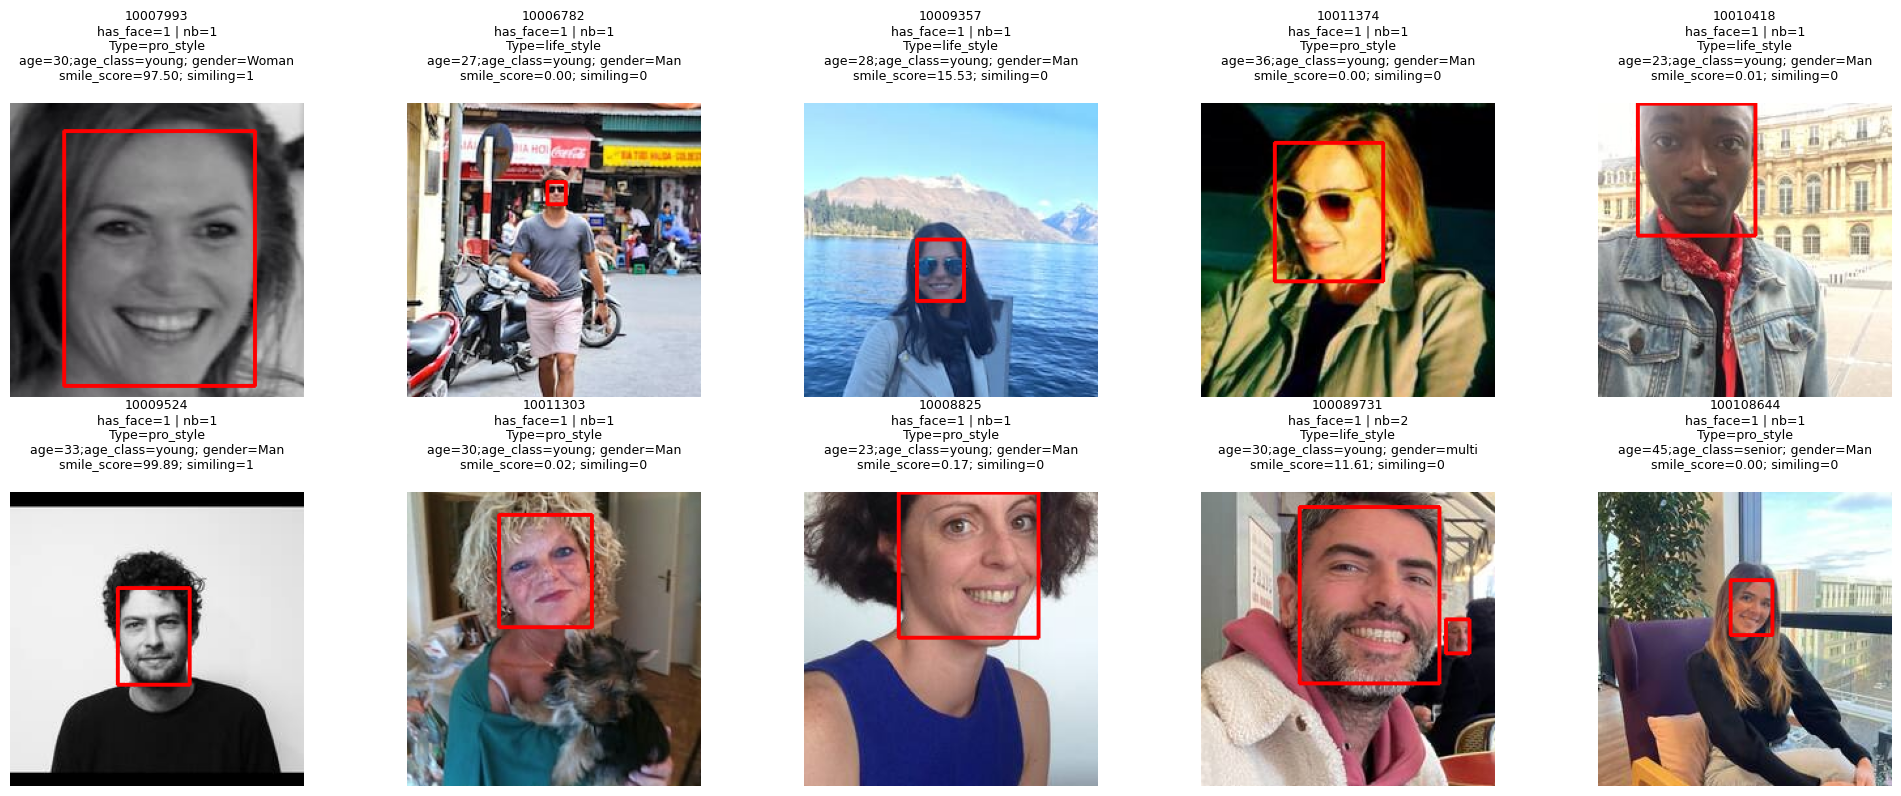

In [10]:
PATH_RESULT=f"results/deepface_results_paris10.json"
with open(PATH_RESULT, 'r', encoding='utf-8')as f:
    results=json.load(f)    

visualize_face_results(results, n_samples=30, seed=42)
